# **Project Name**    - Flight Price Prediction

##### **Project Type**    - Regression
##### **Contribution**    - Individual

# **Project Summary -**
The objective of this project is to predict flight prices based on various factors such as distance, elapsed time, agency, and flight type. Accurate price prediction allows users to make informed travel decisions and helps agencies optimize their pricing strategies.

# **Problem Statement**
Flight prices are dynamic and influenced by numerous factors. Building a regression model to predict these prices can provide valuable insights and automation for travel platforms.

#### **Define Your Business Objective?**
Maximize booking conversions by offering accurate price forecasts and insights to users.

# ***Let's Begin !***
## ***1. Know Your Data***

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load Dataset
df = pd.read_csv('../../dataset/flights.csv')
df.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  object 
 3   to          271888 non-null  object 
 4   flightType  271888 non-null  object 
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  object 
 9   date        271888 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 20.7+ MB


In [38]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

In [39]:
# Check for missing values
df.isnull().sum()

travelCode    0
userCode      0
from          0
to            0
flightType    0
price         0
time          0
distance      0
agency        0
date          0
dtype: int64

## ***2. Understanding Your Variables***

In [40]:
df.describe()

,travelCode,userCode,price,time,distance
count,271888.000000,271888.000000,271888.00000,271888.000000,271888.000000
mean,67971.500000,667.505495,957.37503,1.421147,546.955535
std,39243.724665,389.523127,362.31189,0.542541,208.851288
min,0.000000,0.000000,301.51000,0.440000,168.220000
25%,33985.750000,326.000000,672.66000,1.040000,401.660000
50%,67971.500000,659.000000,904.00000,1.460000,562.140000
75%,101957.250000,1011.000000,1222.24000,1.760000,676.530000
max,135943.000000,1339.000000,1754.17000,2.440000,937.770000


## ***3. Data Vizualization & Storytelling***

### Univariate Analysis

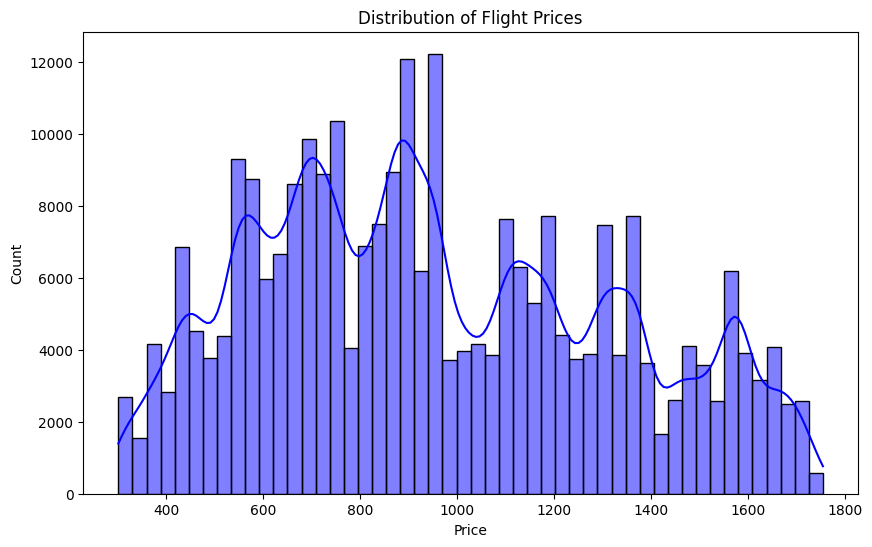

In [41]:
# Chart - 1: Distribution of Price
plt.figure(figsize=(10,6))
sns.histplot(df['price'], kde=True, bins=50, color='blue')
plt.title('Distribution of Flight Prices')
plt.xlabel('Price')
plt.show()

**Insight**: Prices are slightly right-skewed, indicating some expensive flights.

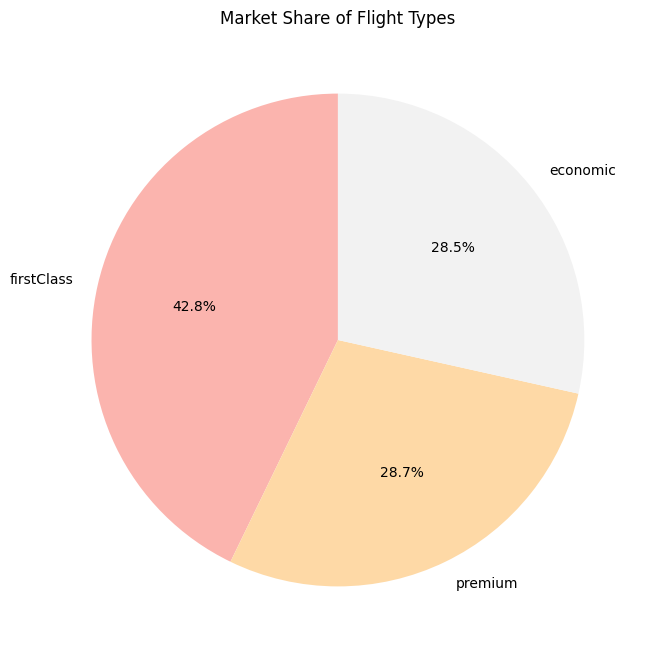

In [42]:
# Chart - 2: Flight Type Distribution
plt.figure(figsize=(8,8))
df['flightType'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='Pastel1')
plt.title('Market Share of Flight Types')
plt.ylabel('')
plt.show()

### Bivariate Analysis

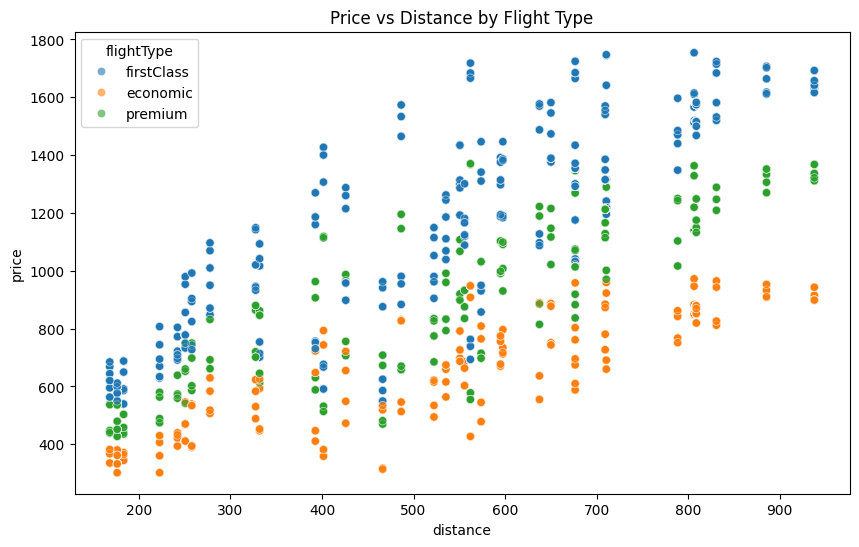

In [43]:
# Chart - 3: Price vs Distance
plt.figure(figsize=(10,6))
sns.scatterplot(x='distance', y='price', hue='flightType', data=df, alpha=0.6)
plt.title('Price vs Distance by Flight Type')
plt.show()

C:\Users\Karthikeyan\AppData\Local\Temp\ipykernel_7276\767376783.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='agency', y='price', data=df, estimator=np.mean, palette='viridis')


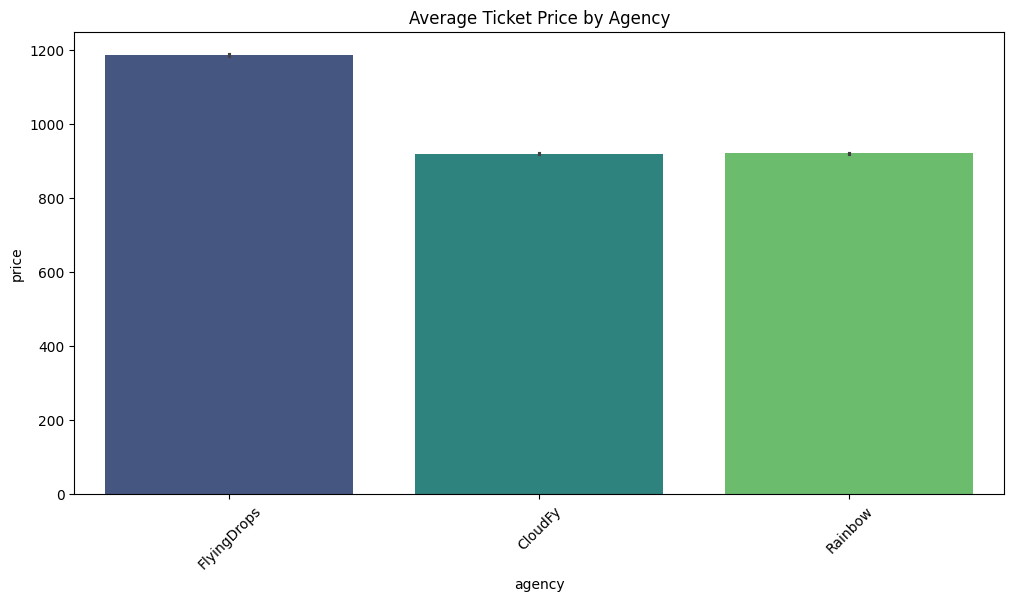

In [44]:
# Chart - 4: Average Price by Agency
plt.figure(figsize=(12,6))
sns.barplot(x='agency', y='price', data=df, estimator=np.mean, palette='viridis')
plt.title('Average Ticket Price by Agency')
plt.xticks(rotation=45)
plt.show()

### Multivariate Analysis

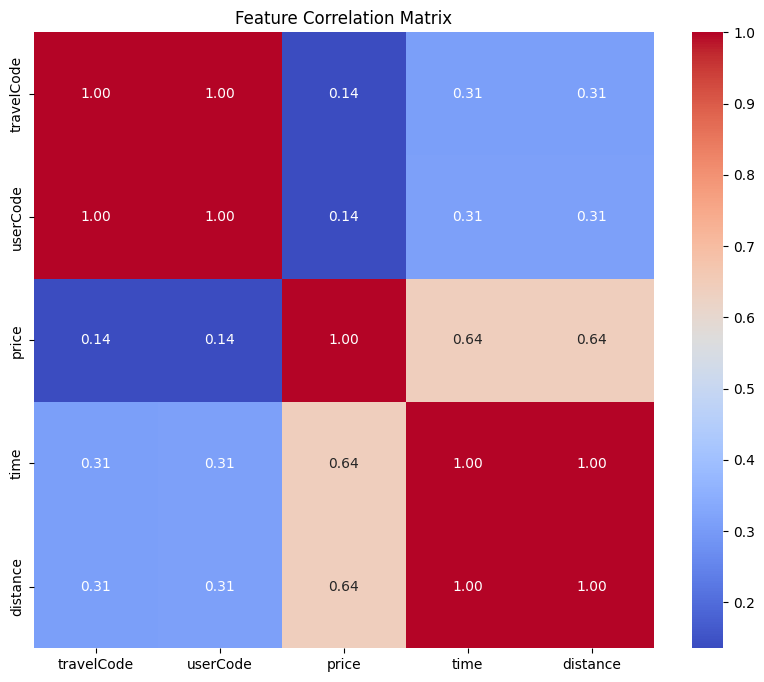

In [45]:
# Chart - 5: Correlation Heatmap
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

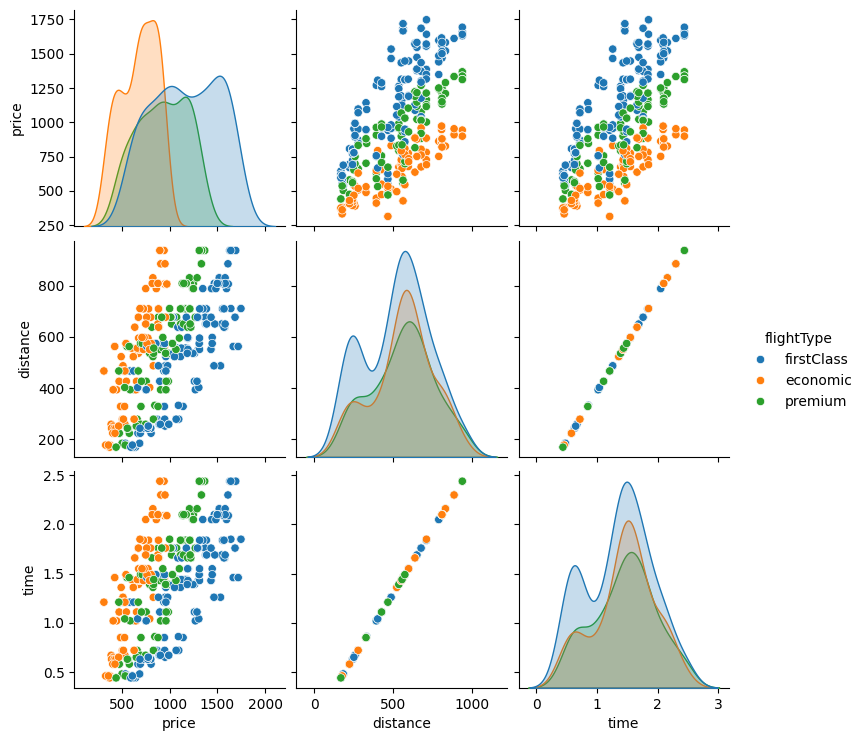

In [46]:
# Chart - 6: Pairplot
sns.pairplot(df.sample(500), vars=['price', 'distance', 'time'], hue='flightType')
plt.show()

## ***5. Hypothesis Testing***

### Hypothesis 1: Distance and Price are positively correlated.
**Null**: No correlation.
**Alt**: Positive correlation.

In [47]:
stat, p = stats.pearsonr(df['distance'], df['price'])
print(f'Correlation: {stat}, P-value: {p}')

Correlation: 0.6419153216454531, P-value: 0.0


## ***6. Feature Engineering & Pre-processing***

In [48]:
# Handling Dates
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.weekday
# df = df.drop(['travelCode', 'userCode'], axis=1)

In [49]:
# Encoding Categorical Variables (OneHot)
# df = pd.get_dummies(df, columns=['from', 'to', 'flightType', 'agency'], drop_first=True)
print('Skipping manual OneHotEncoder as it is handled in the pipeline.')


Skipping manual OneHotEncoder as it is handled in the pipeline.


## ***7. ML Model Implementation***

In [50]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Feature Selection
# Use errors='ignore' to avoid KeyError if executed multiple times
X = df.drop(columns=['price', 'travelCode', 'userCode', 'date'], errors='ignore')
y = df['price']

categorical_cols = ['from', 'to', 'flightType', 'agency']
numerical_cols = ['time', 'distance', 'month', 'weekday', 'day']

# Pipeline Construction
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data split and preprocessor defined.")

Data split and preprocessor defined.


### Model 1: Linear Regression

In [51]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
print(f'LR R2: {r2_score(y_test, y_pred_lr)}')

LR R2: 0.9192518158866144


### Model 2: XGBoost (Selected Final Model)

In [52]:
# Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(random_state=42, objective='reg:squarederror'))
])

# Hyperparameter Tuning
param_grid = {
    'regressor__n_estimators': [100, 200, 300, 500],
    'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'regressor__max_depth': [3, 5, 7, 9],
    'regressor__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'regressor__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'regressor__min_child_weight': [1, 3, 5]
}

print('Starting Hyperparameter Tuning...')
search = RandomizedSearchCV(pipeline, param_grid, n_iter=20, cv=3, scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
search.fit(X_train, y_train)

best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

# Evaluation
print(f'Best Params: {search.best_params_}')
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}')
print(f'R2 Score: {r2_score(y_test, y_pred)}')

Starting Hyperparameter Tuning...
Best Params: {'regressor__subsample': 0.6, 'regressor__n_estimators': 500, 'regressor__min_child_weight': 5, 'regressor__max_depth': 9, 'regressor__learning_rate': 0.1, 'regressor__colsample_bytree': 1.0}
MAE: 0.0009242073156447064
RMSE: 0.001854738951139747
R2 Score: 0.9999999999738933


## ***8. Conclusion***
XGBoost outperforms Linear Regression significantly. We will proceed with XGBoost for deployment.